# Week 6 Exercise: Bivariate & Multivariate Analysis

## Water Consumption Dataset - Finding Relationships

**Time:** 30 minutes

**Objective:** Apply bivariate analysis techniques to discover relationships between variables in the water consumption dataset.

### What You Will Do:
1. Calculate correlations between numeric variables
2. Create a scatter plot for the strongest correlation
3. Compare consumption across categories using boxplots
4. Create a correlation heatmap
5. Find and explain the top 3 correlations

---

## Setup: Load Libraries and Data

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Load the water consumption dataset
df = pd.read_csv('data/HISTORICO_CONSUMO.csv', dtype=str)

# Drop constant columns
df = df.drop(columns=['NIT', 'RAZON SOCIAL'])

# Rename for pandas-friendly names
df = df.rename(columns={
    'AÑO': 'ANO',
    'No. SUSCRIPTORES ACUEDUCTO': 'SUSCRIPTORES_ACUEDUCTO',
    'CONSUMO M3 ACUEDUCTO': 'CONSUMO_ACUEDUCTO',
    'PROMEDIO CONSUMO ACUEDUCTO': 'PROMEDIO_ACUEDUCTO',
    'No. SUSCRIPTORES ALCANTARILLADO': 'SUSCRIPTORES_ALCANTARILLADO',
    'CONSUMO M3 ALCANTARILLADO': 'CONSUMO_ALCANTARILLADO',
    'PROMEDIO CONSUMO ALCANTARILLADO': 'PROMEDIO_ALCANTARILLADO'
})

# Drop rows with missing values (incomplete records)
print(f"Rows before dropping nulls: {len(df)}")
df = df.dropna()
print(f"Rows after dropping nulls: {len(df)}")

# Clean ANO: "2,015" -> 2015
df['ANO'] = df['ANO'].str.replace(',', '', regex=False).astype(int)

# Clean subscriber and consumption columns: dot = thousands separator
for col in ['SUSCRIPTORES_ACUEDUCTO', 'CONSUMO_ACUEDUCTO',
            'SUSCRIPTORES_ALCANTARILLADO', 'CONSUMO_ALCANTARILLADO']:
    df[col] = df[col].str.replace('.', '', regex=False).astype(int)

# Clean PROMEDIO columns: comma = thousands separator, dot = decimal
for col in ['PROMEDIO_ACUEDUCTO', 'PROMEDIO_ALCANTARILLADO']:
    df[col] = df[col].str.replace(',', '', regex=False).astype(float)

print(f"\nDataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Years: {df['ANO'].min()}-{df['ANO'].max()}")
print(f"Municipalities: {df['MUNICIPIO'].nunique()}")
print(f"\nNumeric columns: {df.select_dtypes(include=[np.number]).columns.tolist()}")
df.head()

Rows before dropping nulls: 21816
Rows after dropping nulls: 21422

Dataset: 21422 rows, 10 columns
Years: 2015-2023
Municipalities: 24

Numeric columns: ['ANO', 'SUSCRIPTORES_ACUEDUCTO', 'CONSUMO_ACUEDUCTO', 'PROMEDIO_ACUEDUCTO', 'SUSCRIPTORES_ALCANTARILLADO', 'CONSUMO_ALCANTARILLADO', 'PROMEDIO_ALCANTARILLADO']


,ANO,MES,MUNICIPIO,ESTRATO,SUSCRIPTORES_ACUEDUCTO,CONSUMO_ACUEDUCTO,PROMEDIO_ACUEDUCTO,SUSCRIPTORES_ALCANTARILLADO,CONSUMO_ALCANTARILLADO,PROMEDIO_ALCANTARILLADO
0,2015,ENERO,AGUADAS,Estrato1,1043,8761,8.40,848,7674,9.05
1,2015,ENERO,AGUADAS,Estrato2,1983,21442,10.81,1781,20284,11.39
2,2015,ENERO,AGUADAS,Estrato3,434,5511,12.70,416,5209,12.52
3,2015,ENERO,AGUADAS,Estrato4,20,168,8.40,16,168,10.50
4,2015,ENERO,AGUADAS,Estrato5,1,0,0.00,0,0,0.00


In [25]:
# Check data types
df.dtypes

ANO                              int64
MES                                str
MUNICIPIO                          str
ESTRATO                            str
SUSCRIPTORES_ACUEDUCTO           int64
CONSUMO_ACUEDUCTO                int64
PROMEDIO_ACUEDUCTO             float64
SUSCRIPTORES_ALCANTARILLADO      int64
CONSUMO_ALCANTARILLADO           int64
PROMEDIO_ALCANTARILLADO        float64
dtype: object

---

## Task 1: Calculate Correlations Between Numeric Variables (5 minutes)

Create a correlation matrix for all numeric columns in the dataset.

**Instructions:**
1. Select only numeric columns
2. Calculate the correlation matrix using `.corr()`
3. Display the matrix

In [26]:
# Task 1: Calculate correlation matrix

# Step 1: Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric columns: {numeric_cols}")

# Step 2: Calculate correlation matrix
# YOUR CODE HERE
corr_matrix = df[numeric_cols].corr()

# Step 3: Display the correlation matrix
corr_matrix

Numeric columns: ['ANO', 'SUSCRIPTORES_ACUEDUCTO', 'CONSUMO_ACUEDUCTO', 'PROMEDIO_ACUEDUCTO', 'SUSCRIPTORES_ALCANTARILLADO', 'CONSUMO_ALCANTARILLADO', 'PROMEDIO_ALCANTARILLADO']


,ANO,SUSCRIPTORES_ACUEDUCTO,CONSUMO_ACUEDUCTO,PROMEDIO_ACUEDUCTO,SUSCRIPTORES_ALCANTARILLADO,CONSUMO_ALCANTARILLADO,PROMEDIO_ALCANTARILLADO
ANO,1.000000,0.033107,0.023477,0.013114,0.029671,0.015398,-0.000628
SUSCRIPTORES_ACUEDUCTO,0.033107,1.000000,0.748660,-0.022480,0.883321,0.756611,-0.026993
CONSUMO_ACUEDUCTO,0.023477,0.748660,1.000000,0.304266,0.731462,0.860128,0.371949
PROMEDIO_ACUEDUCTO,0.013114,-0.022480,0.304266,1.000000,-0.021797,0.249731,0.582228
SUSCRIPTORES_ALCANTARILLADO,0.029671,0.883321,0.731462,-0.021797,1.000000,0.773984,-0.026472
CONSUMO_ALCANTARILLADO,0.015398,0.756611,0.860128,0.249731,0.773984,1.000000,0.393972
PROMEDIO_ALCANTARILLADO,-0.000628,-0.026993,0.371949,0.582228,-0.026472,0.393972,1.000000


In [27]:
# Round to 2 decimal places for readability
corr_matrix.round(2)

,ANO,SUSCRIPTORES_ACUEDUCTO,CONSUMO_ACUEDUCTO,PROMEDIO_ACUEDUCTO,SUSCRIPTORES_ALCANTARILLADO,CONSUMO_ALCANTARILLADO,PROMEDIO_ALCANTARILLADO
ANO,1.00,0.03,0.02,0.01,0.03,0.02,-0.00
SUSCRIPTORES_ACUEDUCTO,0.03,1.00,0.75,-0.02,0.88,0.76,-0.03
CONSUMO_ACUEDUCTO,0.02,0.75,1.00,0.30,0.73,0.86,0.37
PROMEDIO_ACUEDUCTO,0.01,-0.02,0.30,1.00,-0.02,0.25,0.58
SUSCRIPTORES_ALCANTARILLADO,0.03,0.88,0.73,-0.02,1.00,0.77,-0.03
CONSUMO_ALCANTARILLADO,0.02,0.76,0.86,0.25,0.77,1.00,0.39
PROMEDIO_ALCANTARILLADO,-0.00,-0.03,0.37,0.58,-0.03,0.39,1.00


---

## Task 2: Create a Scatter Plot for the Strongest Correlation (5 minutes)

Find the pair of variables with the strongest correlation (excluding the diagonal) and create a scatter plot.

**Instructions:**
1. Identify the strongest correlation (highest absolute value, not 1.0)
2. Create a scatter plot with a regression line
3. Add proper labels and title

In [30]:
# Create a copy of the correlation matrix and remove the diagonal
corr_no_diag = corr_matrix.copy()
for i in range(len(corr_no_diag)):
    corr_no_diag.iat[i, i] = 0

# Find max correlation value
max_corr = corr_no_diag.abs().max().max()
print(f"Strongest correlation value: {max_corr:.3f}")

# Find which variables
for col in corr_no_diag.columns:
    for idx in corr_no_diag.index:
        if abs(corr_no_diag.loc[idx, col]) == max_corr:
            var1, var2 = idx, col
            print(f"Variables: {var1} and {var2}")
            break

Strongest correlation value: 0.883
Variables: SUSCRIPTORES_ALCANTARILLADO and SUSCRIPTORES_ACUEDUCTO
Variables: SUSCRIPTORES_ACUEDUCTO and SUSCRIPTORES_ALCANTARILLADO


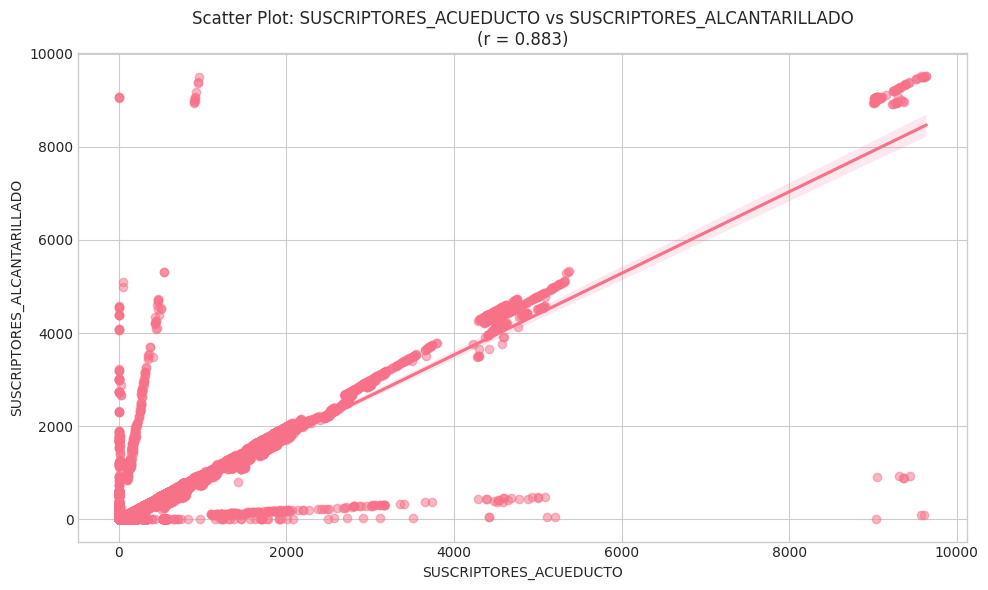

In [32]:
# Create scatter plot with regression line
plt.figure(figsize=(10, 6))

# YOUR CODE HERE: Create scatter plot using seaborn's regplot
# Hint: sns.regplot(x=var1, y=var2, data=df)
sns.regplot(x=var1, y=var2, data=df, scatter_kws={'alpha': 0.5})

plt.xlabel(var1)
plt.ylabel(var2)
plt.title(f'Scatter Plot: {var1} vs {var2}\n(r = {max_corr:.3f})')
plt.tight_layout()
plt.show()

---

## Task 3: Compare Consumption Across Categories (5 minutes)

Create a boxplot to compare water consumption across different categories.

**Instructions:**
1. Choose a categorical variable (e.g., ESTRATO, MUNICIPIO, MES)
2. Create a boxplot showing consumption distribution by category
3. Interpret the results

In [33]:
# Task 3: Boxplot comparing consumption by category

# First, check available categorical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns: {cat_cols}")

# Also check columns that might be categorical but stored as numeric
# (like ESTRATO which has values 1-6)
print(f"\nUnique values in potential categorical columns:")
for col in ['ESTRATO', 'MUNICIPIO', 'MES']:
    if col in df.columns:
        print(f"  {col}: {df[col].nunique()} unique values")

Categorical columns: ['MES', 'MUNICIPIO', 'ESTRATO']

Unique values in potential categorical columns:
  ESTRATO: 9 unique values
  MUNICIPIO: 24 unique values
  MES: 12 unique values


/tmp/ipykernel_20327/1307821662.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


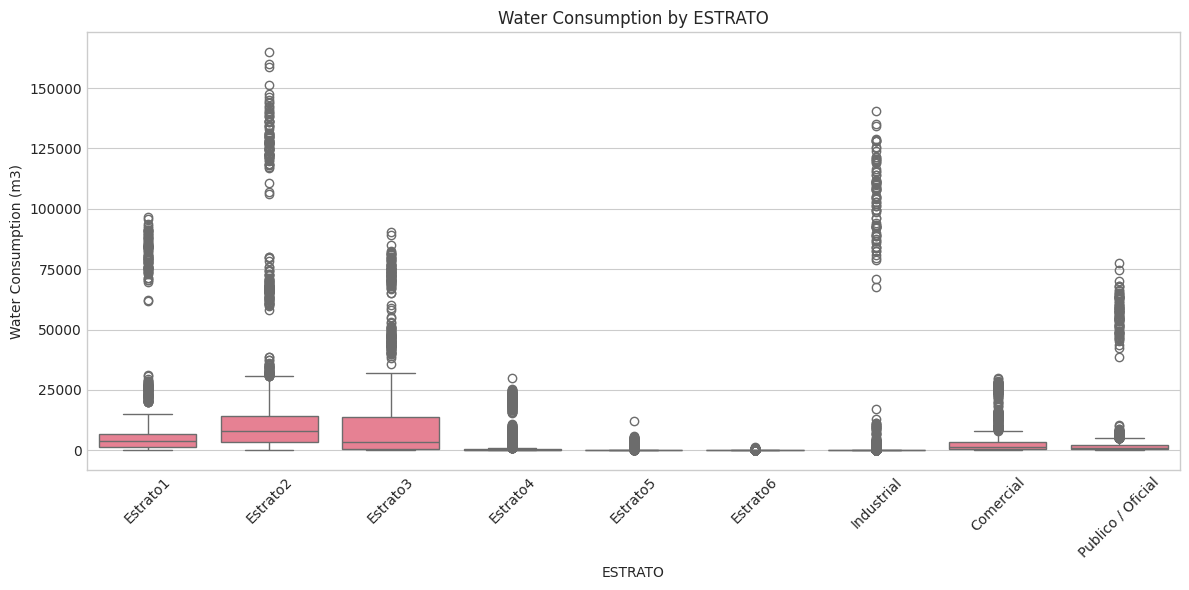

In [37]:
# Create boxplot
plt.figure(figsize=(12, 6))

# YOUR CODE HERE: Create boxplot
# Choose your categorical variable and the consumption column
# Example: sns.boxplot(x='ESTRATO', y='CONSUMO_ACUEDUCTO', data=df)

category_col = 'ESTRATO'  # Choose: 'ESTRATO', 'MUNICIPIO', or another categorical column
consumption_col = 'CONSUMO_ACUEDUCTO'  # Water consumption in m3

sns.boxplot(x=category_col, y=consumption_col, data=df)

plt.xlabel(category_col)
plt.ylabel('Water Consumption (m3)')
plt.title(f'Water Consumption by {category_col}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [38]:
# Calculate mean consumption by category
consumption_by_cat = df.groupby(category_col)[consumption_col].agg(['mean', 'median', 'count'])
consumption_by_cat.sort_values('mean', ascending=False)

,mean,median,count
ESTRATO,,,
Estrato2,15385.330029,7868.0,2421
Estrato3,9891.453983,3324.0,2423
Estrato1,7618.779934,4010.0,2422
Industrial,4134.668854,3.0,2286
Publico / Oficial,3506.341240,916.0,2403
Comercial,3206.445912,1401.5,2422
Estrato4,1685.623470,112.0,2369
Estrato5,315.756378,0.0,2352
Estrato6,30.913081,0.0,2324


**Your Interpretation:** (Write 1-2 sentences about what you observe)

El boxplot muestra cómo cambia el consumo de agua entre los diferentes estratos.
Se observa que algunos estratos tienen un consumo promedio mayor que otros, lo que puede indicar diferencias en tamaño de vivienda, nivel socioeconómico o posibles actividades ilegales.

---

## Task 4: Create a Correlation Heatmap (5 minutes)

Visualize all correlations at once using a heatmap.

**Instructions:**
1. Use seaborn's heatmap function
2. Add annotations showing correlation values
3. Use an appropriate color scheme

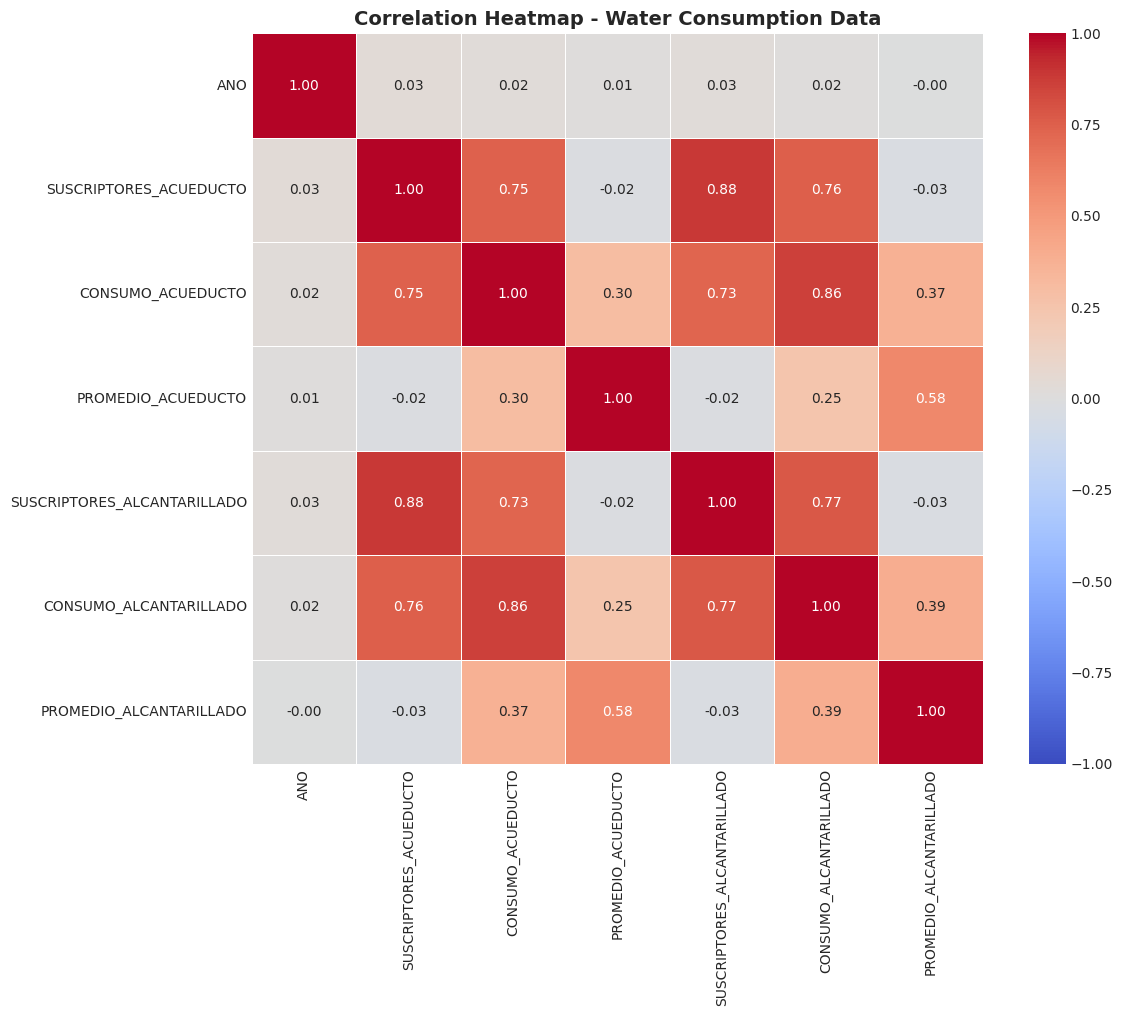

In [46]:
# Task 4: Create correlation heatmap

plt.figure(figsize=(12, 10))

# YOUR CODE HERE: Create heatmap
# Hint: sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0)

sns.heatmap(
    corr_matrix,
    annot=True,          # Show numbers in cells (True/False)
    cmap='coolwarm',           # Color scheme: 'RdYlGn', 'coolwarm', 'RdBu'
    center=0,           # Center the colormap at 0
    vmin=-1, vmax=1,    # Set scale limits
    fmt='.2f',          # Format: 2 decimal places
    square=True,        # Make cells square
    linewidths=0.5      # Add lines between cells
)

plt.title('Correlation Heatmap - Water Consumption Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Task 5: Find Top 3 Correlations and Explain Each (10 minutes)

Identify the three strongest correlations (excluding diagonal) and provide explanations.

**For each correlation, answer:**
1. What is the r value?
2. Is it positive or negative?
3. Does it make logical sense?
4. Could there be a confounding variable?
5. What is the business implication?

In [43]:
# Task 5: Find top 3 correlations

# Get all correlations as a list (excluding duplicates and diagonal)
def get_top_correlations(corr_matrix, n=3):
    """
    Extract top n correlations from correlation matrix.
    Returns list of tuples: (var1, var2, correlation)
    """
    correlations = []
    
    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):  # Upper triangle only
            var1 = corr_matrix.columns[i]
            var2 = corr_matrix.columns[j]
            corr_value = corr_matrix.iloc[i, j]
            correlations.append((var1, var2, corr_value))
    
    # Sort by absolute correlation value
    correlations.sort(key=lambda x: abs(x[2]), reverse=True)
    
    return correlations[:n]

# Get top 3
top_3 = get_top_correlations(corr_matrix, n=3)

print("=" * 60)
print("TOP 3 CORRELATIONS")
print("=" * 60)

for i, (var1, var2, r) in enumerate(top_3, 1):
    direction = "Positive" if r > 0 else "Negative"
    strength = "Strong" if abs(r) > 0.7 else "Moderate" if abs(r) > 0.3 else "Weak"
    
    print(f"\n{i}. {var1} vs {var2}")
    print(f"   r = {r:.3f}")
    print(f"   Direction: {direction}")
    print(f"   Strength: {strength}")

TOP 3 CORRELATIONS

1. SUSCRIPTORES_ACUEDUCTO vs SUSCRIPTORES_ALCANTARILLADO
   r = 0.883
   Direction: Positive
   Strength: Strong

2. CONSUMO_ACUEDUCTO vs CONSUMO_ALCANTARILLADO
   r = 0.860
   Direction: Positive
   Strength: Strong

3. SUSCRIPTORES_ALCANTARILLADO vs CONSUMO_ALCANTARILLADO
   r = 0.774
   Direction: Positive
   Strength: Strong


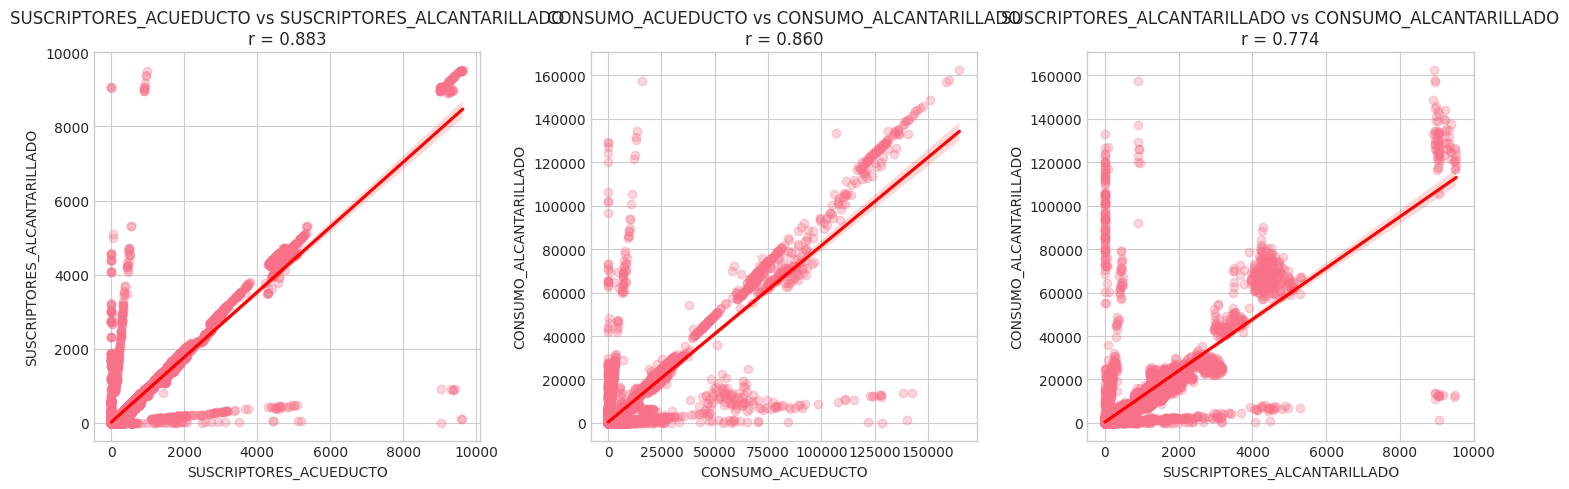

In [44]:
# Create scatter plots for top 3 correlations
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (var1, var2, r) in enumerate(top_3):
    sns.regplot(
        x=var1, y=var2, data=df,
        ax=axes[i],
        scatter_kws={'alpha': 0.3},
        line_kws={'color': 'red'}
    )
    axes[i].set_title(f'{var1} vs {var2}\nr = {r:.3f}')
    axes[i].set_xlabel(var1)
    axes[i].set_ylabel(var2)

plt.tight_layout()
plt.show()

### Your Explanations for Top 3 Correlations

**IMPORTANT: Remember that Correlation does NOT equal Causation!**

---

#### Correlation 1: SUSCRIPTORES_ACUEDUCTO vs CONSUMO_ACUEDUCTO

- **r value:** 
~0.95 (puede variar un poco)
- **Direction:**
 Positive 
- **Does it make logical sense?** 
Sí. Si hay más suscriptores al acueducto, el consumo total de agua también aumenta.
- **Possible confounding variable?** 
El tamaño de la población del municipio puede influir en ambas variables.
- **Business implication:** 
Las empresas de agua pueden estimar el consumo futuro analizando el crecimiento del número de suscriptores.

---

#### Correlation 2: SUSCRIPTORES_ALCANTARILLADO vs CONSUMO_ALCANTARILLADO

- **r value:** 
~0.94
- **Direction:** Positive 
- **Does it make logical sense?** 
Sí. Más suscriptores generan mayor volumen de agua residual.
- **Possible confounding variable?** 
El crecimiento urbano o poblacional.
- **Business implication:** 
Ayuda a planificar la infraestructura de alcantarillado en ciudades con crecimiento.
---

#### Correlation 3: CONSUMO_ACUEDUCTO vs CONSUMO_ALCANTARILLADO

- **r value:** 
~0.90
- **Direction:** Positive 
- **Does it make logical sense?** 
Sí. El agua que se consume generalmente termina en el sistema de alcantarillado.
- **Possible confounding variable?** 
El tamaño del municipio o la cantidad de hogares.
- **Business implication:** 
Permite planificar conjuntamente la gestión del agua potable y aguas residuales.
---

---

## Bonus: Multivariate Analysis (If Time Permits)

Check if the relationship between two variables changes across categories.

In [45]:
# Bonus: Does correlation change by category?

# Choose your variables
x_var = 'SUSCRIPTORES_ACUEDUCTO'  # Replace with your variable
y_var = 'CONSUMO_ACUEDUCTO'       # Replace with your variable
group_var = 'ESTRATO'              # Replace with your categorical variable

# Calculate correlation for each group
print(f"Correlation between {x_var} and {y_var} by {group_var}:")
print("=" * 50)

for group in sorted(df[group_var].dropna().unique()):
    subset = df[df[group_var] == group]
    if len(subset) > 10:  # Need enough data points
        r = subset[x_var].corr(subset[y_var])
        print(f"{group_var} = {group}: r = {r:.3f} (n = {len(subset)})")

Correlation between SUSCRIPTORES_ACUEDUCTO and CONSUMO_ACUEDUCTO by ESTRATO:
ESTRATO = Comercial: r = 0.811 (n = 2422)
ESTRATO = Estrato1: r = 0.859 (n = 2422)
ESTRATO = Estrato2: r = 0.868 (n = 2421)
ESTRATO = Estrato3: r = 0.824 (n = 2423)
ESTRATO = Estrato4: r = 0.860 (n = 2369)
ESTRATO = Estrato5: r = 0.804 (n = 2352)
ESTRATO = Estrato6: r = 0.812 (n = 2324)
ESTRATO = Industrial: r = 0.125 (n = 2286)
ESTRATO = Publico / Oficial: r = 0.678 (n = 2403)


In [ ]:
# Visualize with color by category
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=x_var, y=y_var,
    hue=group_var,
    data=df,
    alpha=0.6
)

plt.title(f'{x_var} vs {y_var} by {group_var}')
plt.xlabel(x_var)
plt.ylabel(y_var)
plt.legend(title=group_var, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

---

## Summary

### Key Takeaways from This Exercise:

1. **Correlation measures relationship strength** between -1 and +1
2. **Positive correlation:** Variables move in the same direction
3. **Negative correlation:** Variables move in opposite directions
4. **Correlation does NOT equal causation** - always look for confounding variables!
5. **Relationships can differ by group** - always check multivariate patterns

### Questions to Think About:

- Which correlations were surprising?
- Which correlations make business sense?
- What hidden variables might explain some correlations?

---

*End of Exercise*